# A06 Appendix Structural Sanity Check

LaTeX slot: `fig:appendix-structure-sanity`

This notebook is intentionally short.

It only keeps two appendix sanity checks:
1. Does the semantic family prior still matter once the main-text compression is removed?
2. Do the macro, mid, and micro roles still matter when temporal scope assignment is perturbed?

Sparse and top-k routing are handled in a separate appendix notebook.

In [ ]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import category_bar_line_plot, setup_style

setup_style()

semantic_df = pd.read_csv(DATA_DIR / 'A06_semantic_variants.csv')
scope_df = pd.read_csv(DATA_DIR / 'A06_scope_layout_variants.csv')

family_prior_labels = {
    'full_semantic': 'Family prior\nintact',
    'reduced_family': 'Fewer semantic\nfamily groups',
    'shuffled_family': 'Family groups\nshuffled',
    'flat_random': 'Flattened scalar\nbag',
}

temporal_role_labels = {
    'original_scope': 'Correct temporal\nroles',
    'identical_scope': 'All stages see\nthe same scope',
    'scope_swap': 'Wrong temporal\nscope assignment',
    'extra_attn': 'Extra attention\nwithout new role',
}

### (a) Semantic family prior still matters

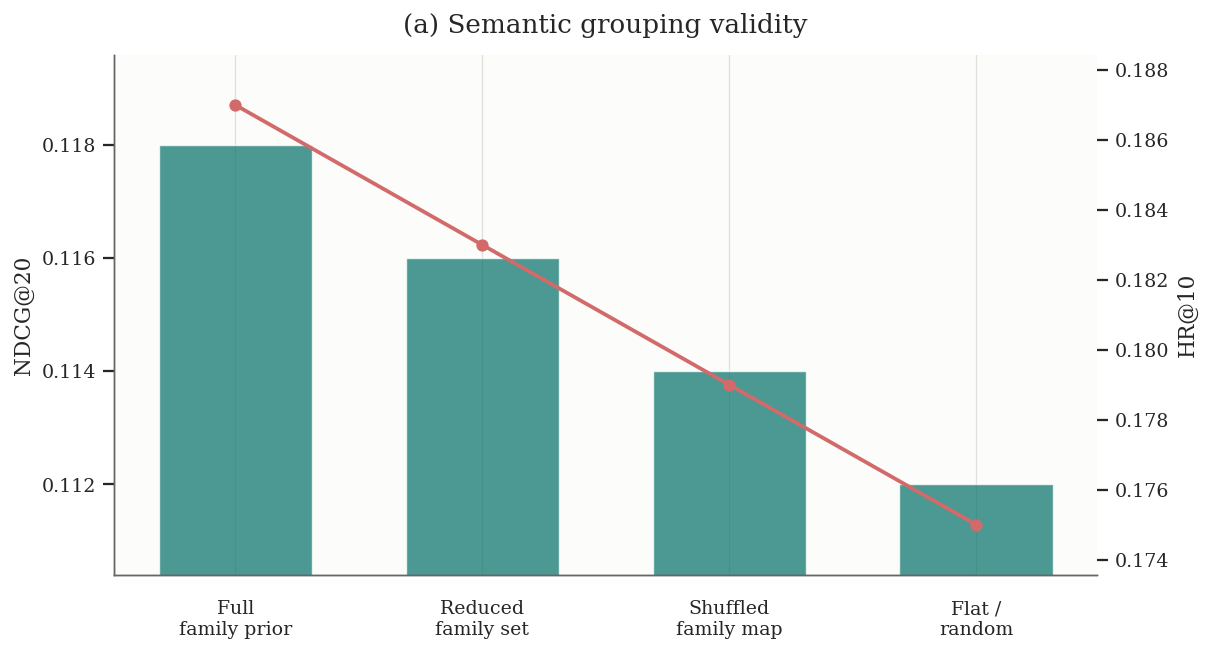

In [ ]:
display(Markdown('### (a) The semantic family prior is not arbitrary'))
fig, ax = plt.subplots(figsize=(9.6, 4.9), constrained_layout=True)
category_bar_line_plot(
    semantic_df,
    category_col='variant',
    bar_col='ndcg20',
    line_col='hr10',
    ax=ax,
    title='(a) Quality after changing the family prior',
    ylabel='NDCG@20',
    xlabel='Family-prior design choice',
    line_label='HR@10',
    order=['full_semantic', 'reduced_family', 'shuffled_family', 'flat_random'],
    category_labels=family_prior_labels,
    rotate=0,
)
ax.tick_params(axis='x', pad=8)
plt.show()

### (b) Stage roles remain meaningful outside the main-text compression

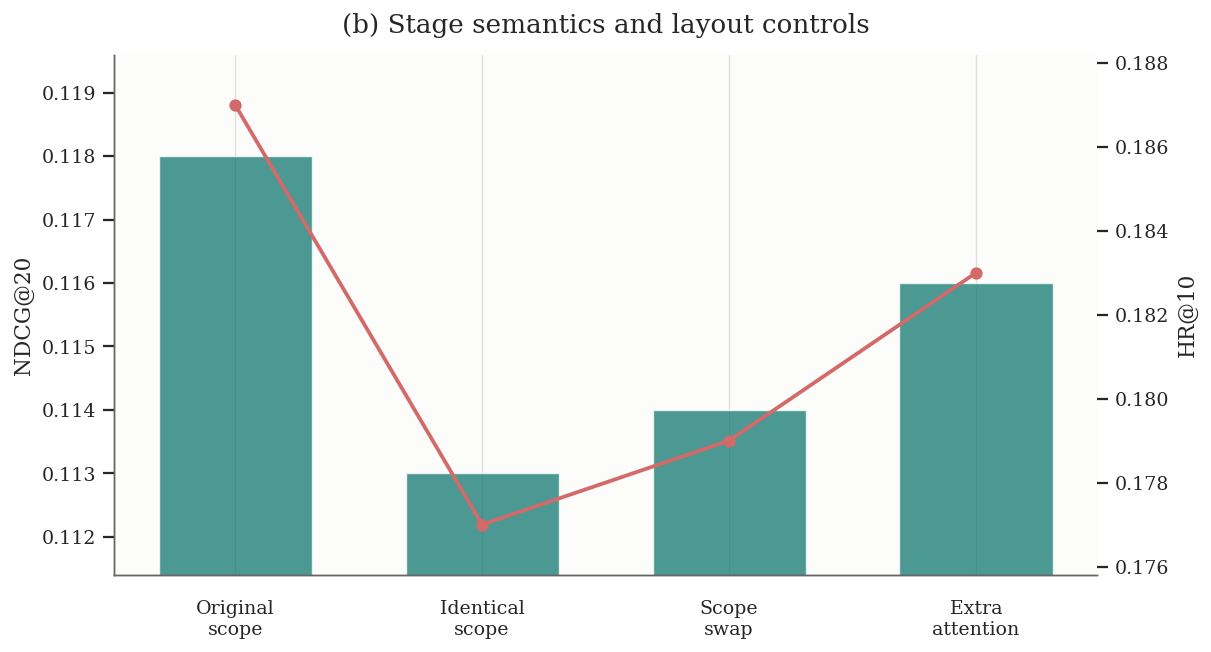

In [ ]:
display(Markdown('### (b) The three stages need distinct temporal roles'))
fig, ax = plt.subplots(figsize=(9.8, 4.9), constrained_layout=True)
category_bar_line_plot(
    scope_df,
    category_col='variant',
    bar_col='ndcg20',
    line_col='hr10',
    ax=ax,
    title='(b) Quality after perturbing temporal role assignment',
    ylabel='NDCG@20',
    xlabel='Temporal-scope design choice',
    line_label='HR@10',
    order=['original_scope', 'identical_scope', 'scope_swap', 'extra_attn'],
    category_labels=temporal_role_labels,
    rotate=0,
)
ax.tick_params(axis='x', pad=8)
plt.show()